<a href="https://colab.research.google.com/github/samuelrossiello/data-analytics-portfolio/blob/main/bootcamp/week5c_real_data_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Exercise 1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset loaded!")
print(df.shape)

Dataset loaded!
(891, 12)


### Exercise 2

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Exercise 3

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Exercise 4

In [ ]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
print(df.isnull().sum() / len(df) * 100)

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


### Exercise 5

In [ ]:
# 1. Drop Cabin — too many missing values to be useful
df = df.drop(columns=["Cabin"])

# 2. Fill Age with median (more robust than mean for skewed data)
df["Age"] = df["Age"].fillna(df["Age"].median())

# 3. Drop the 2 rows with missing Embarked
df = df.dropna(subset=["Embarked"])

# Verify
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### Exercise 6

In [ ]:
# Check for duplicates
print(df.duplicated().sum())

# Drop duplicates if any exist
df = df.drop_duplicates()

0


### Exercise 7

In [ ]:
df["Survived"] = df["Survived"].astype("category")
df["Pclass"] = df["Pclass"].astype("category")

print(df.dtypes)

PassengerId       int64
Survived       category
Pclass         category
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked         object
dtype: object


### Exercise 8

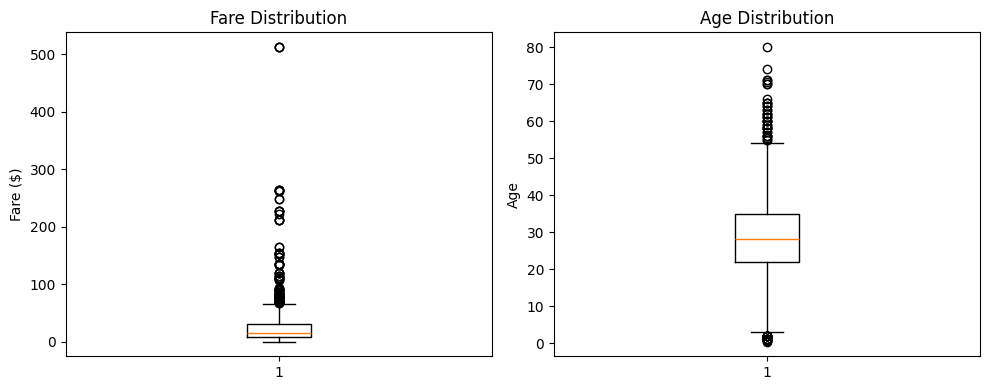

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot(df["Fare"])
axes[0].set_title("Fare Distribution")
axes[0].set_ylabel("Fare ($)")

axes[1].boxplot(df["Age"])
axes[1].set_title("Age Distribution")
axes[1].set_ylabel("Age")

plt.tight_layout()
plt.show()

### Exercise 9

In [ ]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

def clean_titanic(url):
    # Load
    df = pd.read_csv(url)

    # Drop high null column
    df = df.drop(columns=["Cabin"])

    # Fill missing values
    df["Age"] = df["Age"].fillna(df["Age"].median())
    df = df.dropna(subset=["Embarked"])

    # Drop duplicates
    df = df.drop_duplicates()

    # Fix data types
    df["Survived"] = df["Survived"].astype("category")
    df["Pclass"] = df["Pclass"].astype("category")

    return df

df_clean = clean_titanic(url)
print(f"Clean dataset: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")

Clean dataset: 889 rows, 11 columns


### Practice Project

Pclass
1    0.626168
2    0.472826
3    0.242363
Name: Survived_num, dtype: float64


<Axes: xlabel='Pclass', ylabel='Survival_Rate'>

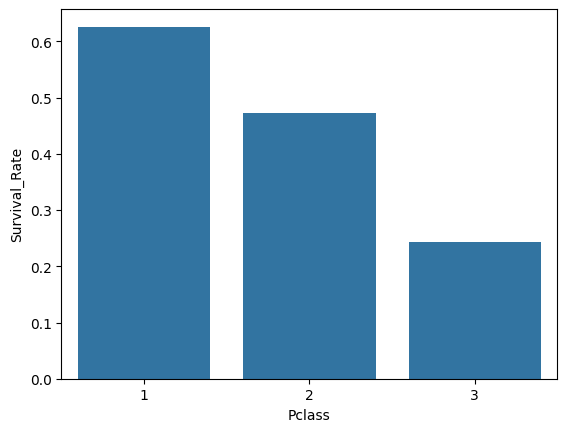

In [ ]:
df_clean["Survived_num"] = df_clean["Survived"].astype(int)
print(df_clean.groupby("Pclass", observed=True)["Survived_num"].mean())

survival_by_class = df_clean.groupby("Pclass", observed=True)["Survived_num"].mean().reset_index()
survival_by_class.columns = ["Pclass", "Survival_Rate"]

sns.barplot(data=survival_by_class, x="Pclass", y="Survival_Rate", errorbar=None)

In [ ]:
print(df_clean.groupby("Survived", observed=True)["Age"].mean())

Survived
0    30.028233
1    28.163735
Name: Age, dtype: float64


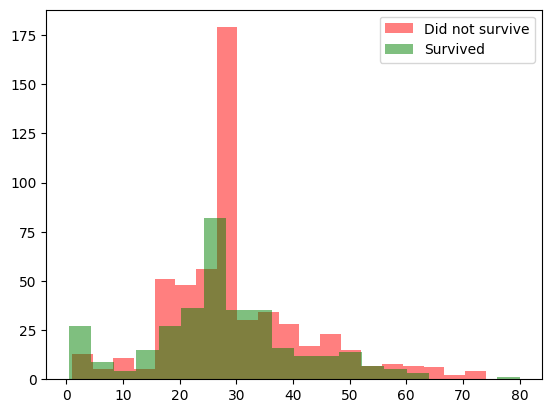

In [ ]:
plt.hist(df_clean[df_clean["Survived_num"] == 0]["Age"], bins=20, alpha=0.5, label="Did not survive", color="red")
plt.hist(df_clean[df_clean["Survived_num"] == 1]["Age"], bins=20, alpha=0.5, label="Survived", color="green")
plt.legend()

In [ ]:
print(df_clean.groupby("Sex", observed=True)["Survived_num"].mean())

Sex
female    0.740385
male      0.188908
Name: Survived_num, dtype: float64
